# ════════════════════════════════════════════════════════
# PHASE 2 — MODÉLISATION : ISOLATION FOREST
# ════════════════════════════════════════════════════════

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import warnings
import pickle
warnings.filterwarnings("ignore")

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score,
    precision_score, recall_score
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("Librairies chargées ✓")

Librairies chargées ✓


# 1. CHARGEMENT DES DONNÉES (depuis Phase 1)

In [108]:
features_df = pd.read_csv('../data/features_ml.csv')
y_labels    = pd.read_csv('../data/y_labels.csv').squeeze()

# Séparer features et labels
X_raw = features_df.drop(columns=['label'], errors='ignore')

print(f'features_ml  : {X_raw.shape}')
print(f'y_labels     : {y_labels.shape}')
print(f'Anomalies    : {y_labels.sum()} ({y_labels.mean()*100:.1f}%)')
print(f'Normal       : {(y_labels==0).sum()}')
print(f'\nDistribution :\n{y_labels.value_counts()}')

features_ml  : (4443, 33)
y_labels     : (4443,)
Anomalies    : 194 (4.4%)
Normal       : 4249

Distribution :
is_anomaly
0    4249
1     194
Name: count, dtype: int64


# 2. ANALYSE DES FEATURES (avant entraînement)

In [110]:
# Vérifier la séparation des features entre Normal et Anomalie
# Si les distributions se chevauchent trop → le modèle aura du mal

df_analysis = X_raw.copy()
df_analysis['label'] = y_labels.values

numeric_cols = df_analysis.select_dtypes(include=[np.number]).drop(columns=['label']).columns

print('=== Moyennes par classe ===')
print(df_analysis.groupby('label')[numeric_cols].mean().T.rename(columns={0: 'Normal', 1: 'Anomalie'}))

# Ratio signal : différence relative entre les classes
means_normal   = df_analysis[df_analysis.label==0][numeric_cols].mean()
means_anomalie = df_analysis[df_analysis.label==1][numeric_cols].mean()
ratio = ((means_anomalie - means_normal) / (means_normal.abs() + 1e-9)).abs()
print('\n=== Ratio de séparation (plus élevé = meilleure feature) ===')
print(ratio.sort_values(ascending=False))

=== Moyennes par classe ===
label                      Normal      Anomalie
server_id                2.002589      2.046392
request_count            1.103083      1.613402
unique_ips               1.103083      1.613402
avg_response_time      159.817486    619.728522
median_response_time   159.817486    602.907216
p95_response_time      168.127712    721.072423
p99_response_time      168.866399    731.641289
max_response_time      169.051071    734.283505
std_response_time       13.058260    134.933402
error_rate_5xx           0.000000      0.500859
error_rate_4xx           0.123088      0.054983
success_rate             0.793363      0.398625
avg_bytes_sent        9056.656272  10677.715206
total_bytes_sent      9967.068957  16490.319588
bot_ratio                0.595434      0.577320
mobile_ratio             0.204872      0.202749
desktop_ratio            0.199694      0.219931
api_ratio                0.446105      0.439433
static_ratio             0.092963      0.091065
auth_ratio  

# 3. TRAIN / TEST SPLIT

In [112]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

scaler = StandardScaler()
numeric_features = X_train_raw.select_dtypes(include=[np.number]).columns
X_train = scaler.fit_transform(X_train_raw[numeric_features])
X_test  = scaler.transform(X_test_raw[numeric_features])

# Sauvegarder le scaler
with open('../data/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f'Train : {X_train.shape[0]} lignes | anomalies : {y_train.sum()}')
print(f'Test  : {X_test.shape[0]} lignes  | anomalies : {y_test.sum()}')

# Entraînement uniquement sur les normaux (approche semi-supervisée)
X_train_normal = X_train[y_train == 0]
print(f'\nEntraînement sur {len(X_train_normal)} samples normaux')

Train : 3554 lignes | anomalies : 155
Test  : 889 lignes  | anomalies : 39

Entraînement sur 3399 samples normaux


# 4. GRID SEARCH : trouver la meilleure contamination

In [113]:
contaminations    = [0.02, 0.03, 0.05, 0.07, 0.10, 0.12, 0.15, 0.20]
n_estimators_list = [100, 200, 300]

results = []
for cont in contaminations:
    for n_est in n_estimators_list:
        model = IsolationForest(
            n_estimators=n_est,
            contamination=cont,
            max_samples='auto',
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train_normal)
        preds  = (model.predict(X_test) == -1).astype(int)
        scores = -model.score_samples(X_test)
        f1  = f1_score(y_test, preds, zero_division=0)
        rec = recall_score(y_test, preds, zero_division=0)
        pre = precision_score(y_test, preds, zero_division=0)
        auc = roc_auc_score(y_test, scores)
        results.append({
            'contamination': cont,
            'n_estimators': n_est,
            'f1': f1,
            'recall': rec,
            'precision': pre,
            'roc_auc': auc
        })

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
print('TOP 10 combinaisons par F1 :')
print(results_df.head(10).to_string(index=False))

TOP 10 combinaisons par F1 :
 contamination  n_estimators       f1   recall  precision  roc_auc
          0.02           300 0.383562 0.358974   0.411765 0.771131
          0.02           200 0.373333 0.358974   0.388889 0.774449
          0.02           100 0.368421 0.358974   0.378378 0.783348
          0.03           100 0.329412 0.358974   0.304348 0.783348
          0.03           200 0.325581 0.358974   0.297872 0.774449
          0.03           300 0.325581 0.358974   0.297872 0.771131
          0.05           200 0.297030 0.384615   0.241935 0.774449
          0.05           300 0.297030 0.384615   0.241935 0.771131
          0.07           200 0.280702 0.410256   0.213333 0.774449
          0.07           300 0.275862 0.410256   0.207792 0.771131


# 4. ENTRAÎNEMENT ISOLATION FOREST

In [115]:
best = results_df.iloc[0]
print(f'Meilleure config : contamination={best.contamination}, n_estimators={int(best.n_estimators)}')

iso_best = IsolationForest(
    n_estimators=int(best.n_estimators),
    contamination=best.contamination,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
iso_best.fit(X_train_normal)

scores_test = -iso_best.score_samples(X_test)
y_pred_base = (iso_best.predict(X_test) == -1).astype(int)

print('\n--- Résultats avec contamination par défaut ---')
print(classification_report(y_test, y_pred_base,
                             target_names=['Normal', 'Anomalie'], digits=3))

Meilleure config : contamination=0.02, n_estimators=300

--- Résultats avec contamination par défaut ---
              precision    recall  f1-score   support

      Normal      0.971     0.976     0.974       850
    Anomalie      0.412     0.359     0.384        39

    accuracy                          0.949       889
   macro avg      0.691     0.668     0.679       889
weighted avg      0.946     0.949     0.948       889



# 6. OPTIMISATION DU SEUIL DE DÉCISION

In [116]:
thresholds = np.linspace(scores_test.min(), scores_test.max(), 200)
best_thresh_f1, best_f1 = 0, 0

for t in thresholds:
    preds = (scores_test >= t).astype(int)
    f1 = f1_score(y_test, preds, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh_f1 = t

# Approche 2 : maximiser le recall en gardant precision > 0.5
best_thresh_recall, best_recall = 0, 0
for t in thresholds:
    preds = (scores_test >= t).astype(int)
    rec  = recall_score(y_test, preds, zero_division=0)
    prec = precision_score(y_test, preds, zero_division=0)
    if rec > best_recall and prec >= 0.4:  # garde un minimum de précision
        best_recall = rec
        best_thresh_recall = t

print(f'Seuil optimal F1       : {best_thresh_f1:.4f}  → F1 = {best_f1:.4f}')
print(f'Seuil optimal Recall   : {best_thresh_recall:.4f}  → Recall = {best_recall:.4f}')

# Choisir selon la priorité métier : ici on veut détecter MAX d'anomalies
# → utiliser le seuil recall si le recall est significativement meilleur
y_pred_final = (scores_test >= best_thresh_f1).astype(int)

print('\n=== RAPPORT FINAL (seuil F1 optimisé) ===')
print(classification_report(y_test, y_pred_final,
                             target_names=['Normal', 'Anomalie'], digits=3))
print(f'ROC-AUC  : {roc_auc_score(y_test, scores_test):.4f}')
print(f'Avg Prec : {average_precision_score(y_test, scores_test):.4f}')

Seuil optimal F1       : 0.6302  → F1 = 0.4286
Seuil optimal Recall   : 0.5908  → Recall = 0.3590

=== RAPPORT FINAL (seuil F1 optimisé) ===
              precision    recall  f1-score   support

      Normal      0.969     0.994     0.981       850
    Anomalie      0.706     0.308     0.429        39

    accuracy                          0.964       889
   macro avg      0.837     0.651     0.705       889
weighted avg      0.957     0.964     0.957       889

ROC-AUC  : 0.7711
Avg Prec : 0.3378


# 7. VISUALISATIONS

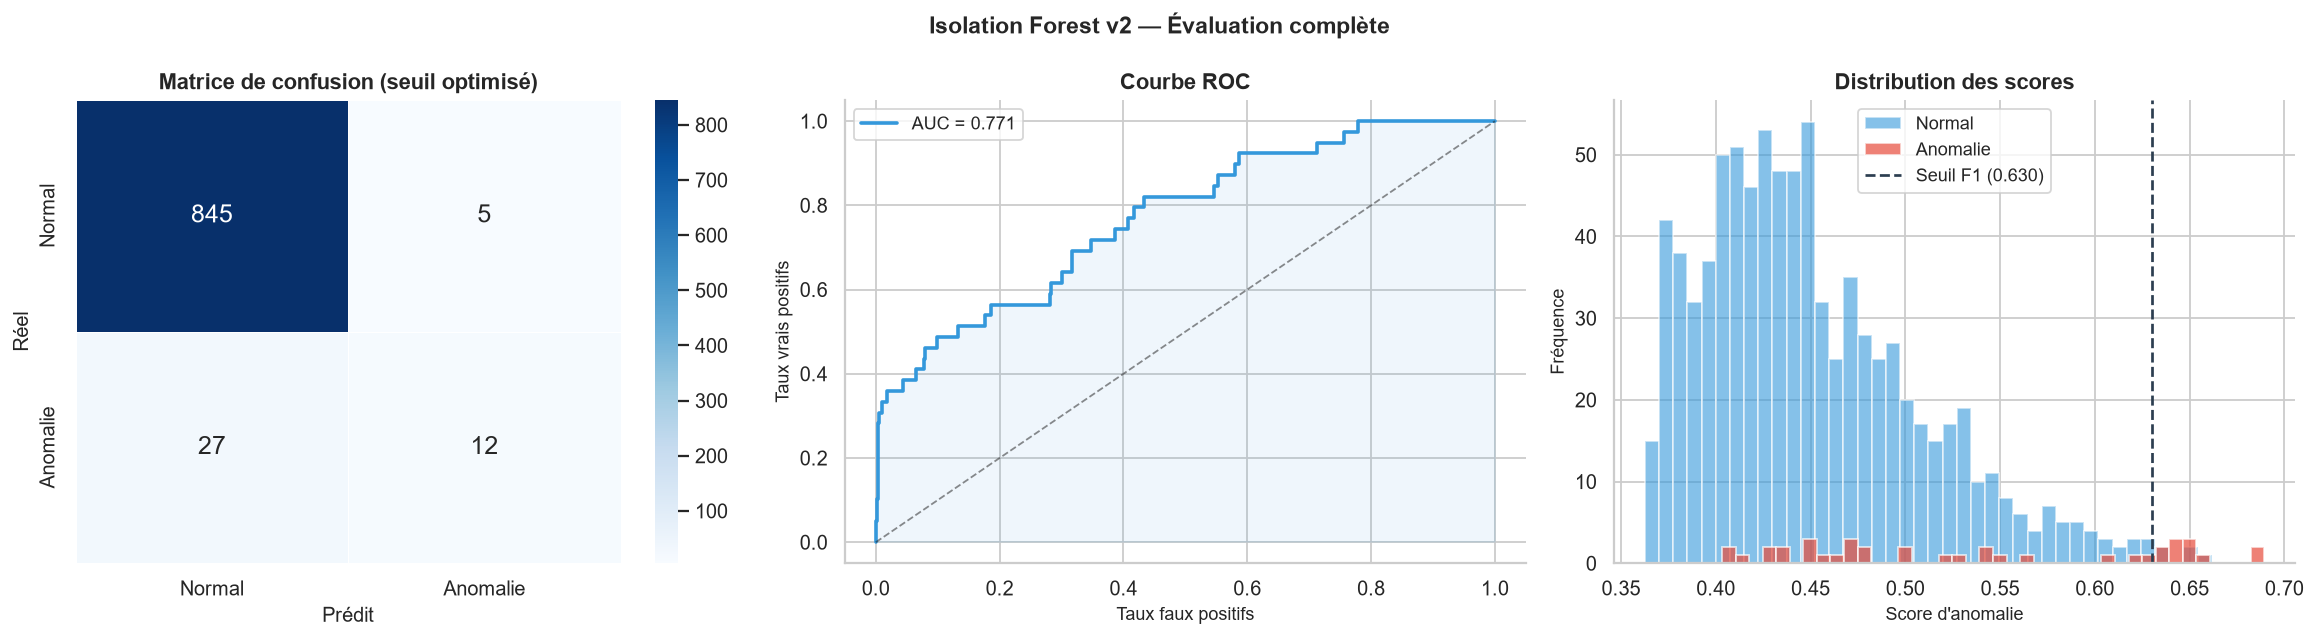

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Matrice de confusion ---
cm = confusion_matrix(y_test, y_pred_final)
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomalie'],
            yticklabels=['Normal', 'Anomalie'],
            linewidths=0.5, ax=ax, annot_kws={'size': 14})
ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.set_title('Matrice de confusion (seuil optimisé)', fontsize=12, fontweight='bold')

# --- Courbe ROC ---
fpr, tpr, _ = roc_curve(y_test, scores_test)
roc_auc = roc_auc_score(y_test, scores_test)
ax2 = axes[1]
ax2.plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {roc_auc:.3f}')
ax2.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
ax2.fill_between(fpr, tpr, alpha=0.08, color='#3498db')
ax2.set_xlabel('Taux faux positifs', fontsize=10)
ax2.set_ylabel('Taux vrais positifs', fontsize=10)
ax2.set_title('Courbe ROC', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

# --- Distribution des scores ---
ax3 = axes[2]
ax3.hist(scores_test[y_test == 0], bins=40, alpha=0.6,
         color='#3498db', label='Normal', edgecolor='white')
ax3.hist(scores_test[y_test == 1], bins=40, alpha=0.7,
         color='#e74c3c', label='Anomalie', edgecolor='white')
ax3.axvline(best_thresh_f1, color='#2c3e50', linestyle='--', lw=1.5,
            label=f'Seuil F1 ({best_thresh_f1:.3f})')
ax3.set_xlabel("Score d'anomalie", fontsize=10)
ax3.set_ylabel('Fréquence', fontsize=10)
ax3.set_title('Distribution des scores', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)

plt.suptitle('Isolation Forest v2 — Évaluation complète', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/evaluation_IF_v2.png', bbox_inches='tight')
plt.show()